# Nhiệm vụ 11 — Final Holdout của mô hình đã đóng băng

Theo phần 11.1–11.10 trong `M2/Ke_hoach_M2_Phan_cum_co_phieu.md`.
Chỉ kiểm định mô hình thắng ở Task 10 trên 7 snapshot 02–08/2026, K=2.
Giữ công thức, feature set, seed và số lần khởi tạo; Robust Scaling/fit riêng mỗi tháng.
Không dùng scaler Development cho Holdout, không quét K, không chạy lại comparators.

**Cách chạy:** chọn kernel Python đã dùng ở M2 rồi Run All. Root được tìm tự động
từ repo hoặc `M2/notebooks`; không cần thêm `%cd`.
Logic Task 11 nằm trong `src/delta_t1/experiments/final_holdout.py`.
Lần đầu tạo bộ kết quả; những lần sau chỉ kiểm tra checksum/nạp evidence, không refit.
Thay quyết định/input sau khi đã mở holdout sẽ làm chương trình dừng.


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / 'configs/experiments/m2_final_holdout_v1.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Chạy notebook từ repo hoặc thư mục M2/notebooks.')
sys.path.insert(0, str(ROOT / 'src'))
from delta_t1.experiments.final_holdout import freeze_gate, run_final_holdout
from delta_t1.experiments.protocol import M2_HOLDOUT_SNAPSHOTS
from delta_t1.io import read_json, read_rows
pd.set_option('display.max_columns', 24)
print('Repo root:', ROOT)


Repo root: C:\Users\HOME\Desktop\M2\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment


## Bước 1 — Kiểm định cổng đóng băng

Kiểm tra trạng thái, timestamp, 15 model/checksum, cùng cấu hình và bảng Task 10.
Chưa đọc holdout ở bước này. Tham số fit lấy từ model đã đóng băng, không tự chọn lại.


In [2]:
gate = freeze_gate(ROOT)
display(pd.DataFrame([dict(selected_method=gate['selected_method'], algorithm=gate['algorithm'],
    global_k=gate['clustering']['k'], k_range=gate['clustering']['k_range'],
    seed=gate['clustering'].get('seed'), n_init=gate['clustering'].get('n_init'),
    max_iter=gate['clustering'].get('max_iter'),
    decision_timestamp=gate['decision']['decision_timestamp'])]))
assert gate['decision']['status'] == 'FROZEN_FOR_HOLDOUT'
assert gate['clustering']['k_range'] == [2]
print('PASS: freeze gate; only selected method can open holdout.')


,selected_method,algorithm,global_k,k_range,seed,n_init,max_iter,decision_timestamp
0,KMeans_Baseline,kmeans,2,[2],42,10,300,2026-10-04T08:01:06+00:00


PASS: freeze gate; only selected method can open holdout.


## Bước 2 — Mở 7 snapshot từ Feature Store 1.6.0

Gọi pipeline một lần: loader C8 kiểm tra hash trước khi trả đúng 7 ngày holdout;
pipeline thực hiện các bước 2–7 và đóng băng exports. Các cell sau trình bày/kiểm tra
kết quả từng bước mà không chạy lại fit. C8 nằm tại đường dẫn artifact active đã freeze,
không cần sao chép hoặc dựng lại feature store ở `data/canonical/market/`.
Nếu kết quả complete đã có, chỉ xác minh và nạp lại artifacts.


In [3]:
target, manifest = run_final_holdout(ROOT)
assert manifest['status'] == 'complete'
assert manifest['methods_executed'] == [gate['algorithm']]
assert manifest['k_values_executed'] == [2]
print('Artifact:', target)
print('Decision freeze:', manifest['decision_timestamp'])
print('Holdout opened:', manifest['holdout_opened_at'])
print('Feature version:', manifest['feature_version'])


Artifact: C:\Users\HOME\Desktop\M2\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment\M2\artifacts\m2-final-holdout-v1
Decision freeze: 2026-10-04T08:01:06+00:00
Holdout opened: 2026-10-04T08:14:18.565783+00:00
Feature version: 1.6.0


## Bước 3 — Universe riêng từng tháng và ngưỡng 120

Không lấy membership tháng 08/2026 áp cho các tháng trước. Nếu dưới 120,
ghi skip/lý do và ngắt chuỗi; không nội suy/gộp dữ liệu.


In [4]:
validation = pd.read_csv(target / 'snapshot_validation.csv')
display(validation)
assert validation.snapshot_date.tolist() == list(M2_HOLDOUT_SNAPSHOTS)
assert validation.loc[validation.status.eq('ready'), 'n_eligible'].ge(120).all()
print('Ready:', manifest['n_snapshots'], '| Skipped:', manifest['n_skipped'])


,snapshot_date,status,n_eligible,reason
0,2026-02-27,ready,253,NaN
1,2026-03-31,ready,520,NaN
2,2026-04-29,ready,521,NaN
3,2026-05-29,ready,782,NaN
4,2026-06-30,ready,782,NaN
5,2026-07-31,ready,861,NaN
6,2026-08-28,ready,905,NaN


Ready: 7 | Skipped: 0


## Bước 4 — Robust Scaling độc lập

`center` là median snapshot, `scale` là IQR (scale=1 nếu IQR=0 theo preprocessing đã freeze).
Scalers nằm trong từng model JSON và bảng riêng để kiểm tra; không dùng scaler development.


In [5]:
scalers = pd.read_csv(target / 'scaler_parameters.csv')
display(scalers[['snapshot_date', 'feature', 'center', 'scale', 'method']])
assert scalers.method.eq('robust_per_snapshot').all()
assert scalers.scale.gt(0).all()
assert len(scalers) == manifest['n_snapshots'] * 8


,snapshot_date,feature,center,scale,method
0,2026-02-27,mom_21,-1.098901e-02,6.951943e-02,robust_per_snapshot
1,2026-02-27,mom_63,-8.643096e-03,1.450960e-01,robust_per_snapshot
2,2026-02-27,mom_126,-2.773462e-02,1.887532e-01,robust_per_snapshot
3,2026-02-27,mom_252,1.135163e-02,3.135739e-01,robust_per_snapshot
4,2026-02-27,vol_63,3.027607e-01,1.573843e-01,robust_per_snapshot
5,2026-02-27,mdd_126,-1.910112e-01,1.420825e-01,robust_per_snapshot
6,2026-02-27,beta_126,3.835710e-01,5.990741e-01,robust_per_snapshot
7,2026-02-27,liquidity_21,2.084522e+09,2.383703e+10,robust_per_snapshot
8,2026-03-31,mom_21,-3.574056e-02,8.550480e-02,robust_per_snapshot
9,2026-03-31,mom_63,-3.136102e-02,1.558550e-01,robust_per_snapshot


## Bước 5 — Assignments, profiles và model của duy nhất phương án thắng

Profiles lấy mean 8 feature gốc từ thành viên thực tế; nhãn raw khác nhãn aligned.
Model/centroid/scaler được lưu dưới `M2/models/holdout/` và trong artifact.


In [6]:
assignments = pd.read_csv(target / 'assignments.csv')
profiles = pd.read_csv(target / 'cluster_profiles.csv')
display(assignments.head(12))
display(profiles)
assert not assignments.duplicated(['snapshot_date', 'security_id']).any()
assert len(assignments) == manifest['n_assignments']
counts = assignments.groupby(['snapshot_date', 'aligned_cluster_id']).size()
assert all(counts.loc[r.snapshot_date, r.aligned_cluster_id] == r.size for r in profiles.itertuples())
assert len(list((ROOT / 'M2/models/holdout').glob('????-??-??.json'))) == manifest['n_snapshots']
print('Assignments:', len(assignments), '| Profiles:', len(profiles))


,snapshot_date,security_id,raw_cluster_id,aligned_cluster_id,run_id,data_version
0,2026-02-27,KBS:HOSE:AAM,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
1,2026-02-27,KBS:HOSE:AAT,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
2,2026-02-27,KBS:HOSE:ABR,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
3,2026-02-27,KBS:HOSE:ABS,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
4,2026-02-27,KBS:HOSE:ABT,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
5,2026-02-27,KBS:HOSE:ACC,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
6,2026-02-27,KBS:HOSE:ACG,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
7,2026-02-27,KBS:HOSE:ACL,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
8,2026-02-27,KBS:HOSE:ADG,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1
9,2026-02-27,KBS:HOSE:ADP,0,1,m2-final-holdout-v1,CAFEF_C8_COMPLETE_ONLY_V1


,snapshot_date,raw_cluster_id,aligned_cluster_id,size,size_ratio,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
0,2026-02-27,0,1,243,0.960474,-0.004598,0.000531,-0.003102,0.089454,0.306076,-0.210384,0.418494,2.455354e+10
1,2026-02-27,1,0,10,0.039526,0.055100,0.308623,0.230192,0.590270,0.384278,-0.203626,0.927630,7.363108e+11
2,2026-03-31,0,1,506,0.973077,-0.025324,-0.019984,-0.055149,0.039768,0.400103,-0.240862,0.386963,1.280986e+10
3,2026-03-31,1,0,14,0.026923,-0.128797,0.071736,0.009414,0.290860,0.498769,-0.304189,0.873652,6.337554e+11
4,2026-04-29,0,1,509,0.976967,-0.002168,-0.038789,-0.026912,0.117577,0.395285,-0.230896,0.354423,1.041915e+10
5,2026-04-29,1,0,12,0.023033,0.061782,0.020071,0.009217,0.535740,0.434732,-0.271011,0.980021,5.462035e+11
6,2026-05-29,0,1,769,0.983376,0.001486,-0.037856,-0.000461,0.095814,0.450899,-0.240545,0.306651,6.785695e+09
7,2026-05-29,1,0,13,0.016624,-0.001313,-0.023116,0.040839,0.351150,0.429821,-0.273369,0.868431,5.034393e+11
8,2026-06-30,0,0,13,0.016624,-0.001722,0.074638,0.048369,0.349562,0.338589,-0.253119,0.748880,4.005365e+11
9,2026-06-30,1,1,769,0.983376,0.005342,-0.002565,-0.009831,0.082831,0.404338,-0.240533,0.295780,4.730164e+09


Assignments: 4624 | Profiles: 14


## Bước 6 — Quality, Temporal Stability, Generalization Gap và Profiles

Chỉ nối tháng holdout liên tiếp đã hợp lệ; không nối 2025-01-24 → 2026-02-27.
ARI/NMI đo cấu trúc, migration/persistence trên mã chung; entry/exit báo riêng.
Không coi migration là chi phí hoặc turnover danh mục.


In [7]:
diagnostics = pd.read_csv(target / 'diagnostics.csv')
quality = pd.read_csv(target / 'quality_summary.csv')
temporal = pd.read_csv(target / 'temporal_stability.csv')
transitions = pd.read_csv(target / 'transition_matrices.csv')
drift = pd.read_csv(target / 'centroid_drift.csv')
gap = pd.read_csv(target / 'holdout_generalization_gap.csv')
display(diagnostics)
display(quality)
display(temporal)
display(gap)
assert diagnostics.k.eq(2).all()
allowed_pairs = set(zip(M2_HOLDOUT_SNAPSHOTS[:-1], M2_HOLDOUT_SNAPSHOTS[1:]))
assert set(zip(temporal.from_date, temporal.to_date)) <= allowed_pairs
assert len(temporal) == manifest['n_temporal_pairs']
for r in temporal.itertuples():
    pair = transitions[transitions.from_date.eq(r.from_date) & transitions.to_date.eq(r.to_date)]
    assert pair['count'].sum() == r.n_common
    assert abs(pair.loc[pair.from_cluster.eq(pair.to_cluster), 'count'].sum() / r.n_common - r.persistence_probability) < 1e-10
assert (abs(drift.value_to-drift.value_from-drift.delta) <= drift.delta.abs()*1e-12 + 1e-8).all()
profile_check = pd.read_csv(target / 'profile_consistency.csv')
display(profile_check.pivot(index=['role','feature'], columns='period', values='mean'))
sil = gap.set_index('metric').loc['silhouette']
print(f"Delta_Silhouette = {sil.holdout_median:.6f} - {sil.development_median:.6f} = {sil.delta_holdout_minus_development:+.6f}")


,snapshot_date,k,silhouette,calinski_harabasz,davies_bouldin,inertia,cluster_sizes,cluster_balance,converged
0,2026-02-27,2,0.843439,448.303564,0.453854,4849.905327,"{""0"": 243, ""1"": 10}",0.041152,True
1,2026-03-31,2,0.929030,1493.208872,0.433678,86901.988766,"{""0"": 506, ""1"": 14}",0.027668,True
2,2026-04-29,2,0.939166,1393.387383,0.314908,118867.255377,"{""0"": 509, ""1"": 12}",0.023576,True
3,2026-05-29,2,0.957256,2479.281435,0.291872,486130.329693,"{""0"": 769, ""1"": 13}",0.016905,True
4,2026-06-30,2,0.958492,2330.382823,0.431560,432647.471068,"{""0"": 13, ""1"": 769}",0.016905,True
5,2026-07-31,2,0.963186,2838.849869,0.360959,702188.306216,"{""0"": 848, ""1"": 13}",0.015330,True
6,2026-08-28,2,0.952683,2526.864046,0.438153,677822.831689,"{""0"": 886, ""1"": 19}",0.021445,True


,metric,n_total,n_available,mean,median,minimum,maximum
0,silhouette,7,7,0.934750,0.952683,0.843439,0.963186
1,davies_bouldin,7,7,0.389283,0.431560,0.291872,0.453854
2,calinski_harabasz,7,7,1930.039713,2330.382823,448.303564,2838.849869
3,inertia,7,7,358486.869734,432647.471068,4849.905327,702188.306216
4,cluster_balance,7,7,0.023283,0.021445,0.015330,0.041152


,from_date,to_date,n_common,ari,nmi,persistence_probability,migration_rate,entered_count,exited_count,status
0,2026-02-27,2026-03-31,253,0.852197,0.751628,0.988142,0.011858,267,0,OK
1,2026-03-31,2026-04-29,520,0.673364,0.487030,0.984615,0.015385,1,0,OK
2,2026-04-29,2026-05-29,520,0.871728,0.751258,0.994231,0.005769,262,1,OK
3,2026-05-29,2026-06-30,781,0.919331,0.831123,0.997439,0.002561,1,1,OK
4,2026-06-30,2026-07-31,781,0.919331,0.831123,0.997439,0.002561,80,1,OK
5,2026-07-31,2026-08-28,861,1.000000,1.000000,1.000000,0.000000,44,0,OK


,metric,development_n,holdout_n,development_median,holdout_median,delta_holdout_minus_development
0,silhouette,15,7,0.755722,0.952683,0.196961
1,davies_bouldin,15,7,0.521899,0.431560,-0.090338
2,calinski_harabasz,15,7,316.391783,2330.382823,2013.991039
3,inertia,15,7,2158.608251,432647.471068,430488.862817
4,cluster_balance,15,7,0.067669,0.021445,-0.046224
5,ari,14,6,0.798251,0.895529,0.097278
6,nmi,14,6,0.661313,0.791375,0.130062
7,persistence_probability,14,6,0.985618,0.995835,0.010217
8,migration_rate,14,6,0.014382,0.004165,-0.010217


period                      development       holdout
role         feature                                 
Higher_mom63 beta_126      1.153144e+00  7.115433e-01
             liquidity_21  3.168300e+11  4.042099e+11
             mdd_126      -2.039459e-01 -2.594561e-01
             mom_126       1.344291e-01  3.121176e-02
             mom_21        2.183876e-02 -7.124956e-03
             mom_252       3.837003e-01  2.939377e-01
             mom_63        8.449971e-02  5.426494e-02
             vol_63        3.299243e-01  4.196599e-01
Lower_mom63  beta_126      7.562037e-01  4.976372e-01
             liquidity_21  6.992401e+10  1.154703e+11
             mdd_126      -1.997158e-01 -2.462381e-01
             mom_126       5.460577e-02 -2.068440e-02
             mom_21        1.852452e-02 -8.531282e-03
             mom_252       1.978154e-01  6.529294e-02
             mom_63        2.293215e-02 -2.910488e-02
             vol_63        3.210512e-01  3.802974e-01

Delta_Silhouette = 0.952683 - 0.755722 = +0.196961


## Bước 7 — Biểu đồ 22 mốc, Manifest và Báo cáo

Biểu đồ có hai đường trung vị, đường đỏ đứt và annotation gap reset;
không nối đường development tới holdout. Manifest kiểm tra toàn bộ exports,
model copies, source snapshot và report. Kết luận dưới đây lấy từ số liệu đã chạy.
Nhiệm vụ 12 và M3 cần thực hiện riêng.


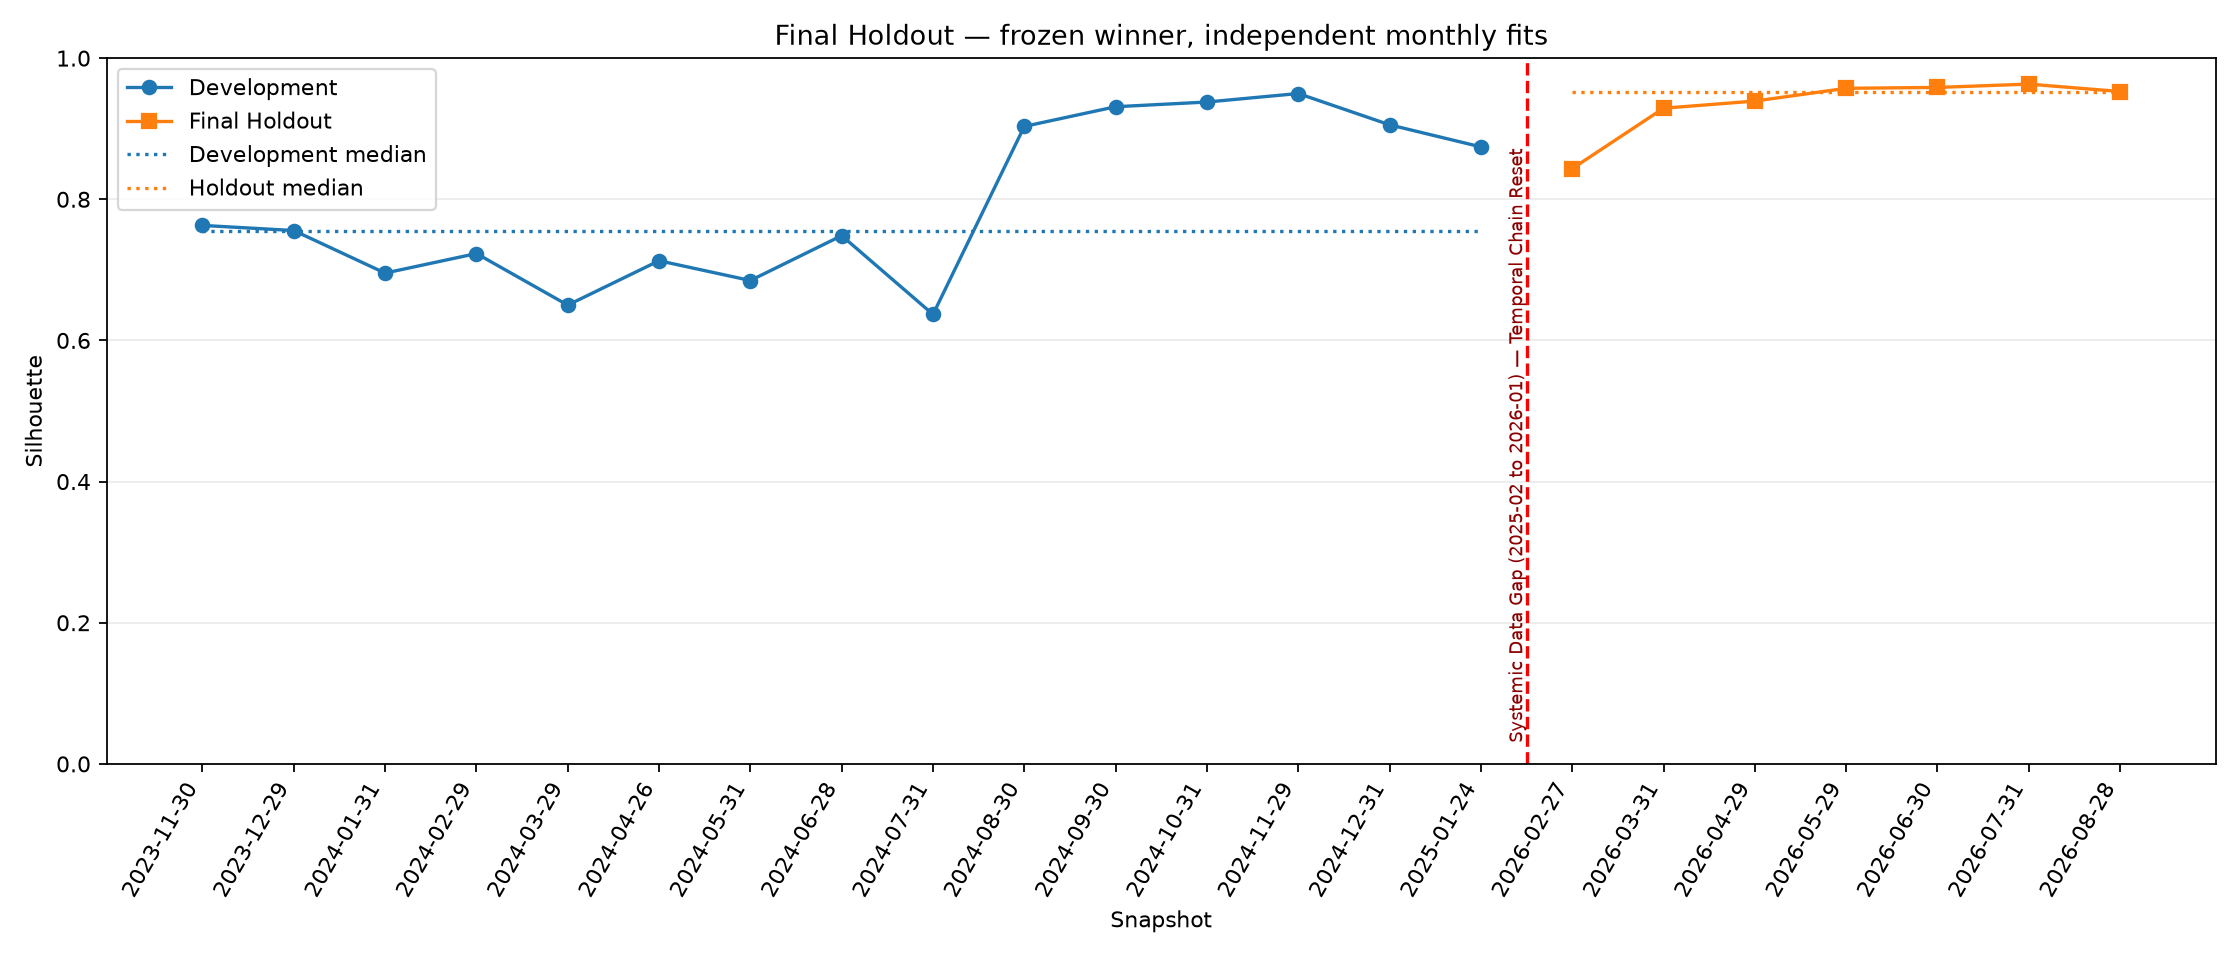

# Báo cáo Nhiệm vụ 11 — Final Holdout

## A — Gate và thực thi một chiều
Mô hình: **KMeans_Baseline**, Global K=2; seed=42,
n_init=10, max_iter=300.
Decision freeze: `2026-10-04T08:01:06+00:00`; mở holdout: `2026-10-04T08:14:18.565783+00:00`.
Chạy 7/7 snapshots, 4624 assignments và 6/6 cặp tháng.
Universe riêng mỗi tháng: 253–905 mã;
skip 0 snapshot. Robust Scaling fit mới từng snapshot;
chỉ algorithm thắng và K=2, không quét K hoặc chạy comparator.
Nguồn Feature Store 1.6.0: C8 checksummed `canonical/feature_snapshots.jsonl`;
không tạo bản sao hoặc sửa nguồn thành `data/canonical/market/`.

## B — Development so với Holdout
| Metric | Median Development | Median Holdout | Holdout − Development |
| --- | ---: | ---: | ---: |
| silhouette | 0.755722 | 0.952683 | +0.196961 |
| davies_bouldin | 0.521899 | 0.431560 | -0.090338 |
| calinski_harabasz | 316.391783 | 2330.382823 | +2013.991039 |
| inertia | 2158.608251 | 432647.471068 | +430488.862817 |
| cluster_balance | 0.067669 | 0.021445 | -0.046224 |
| ari | 0.798251 | 0.895529 | +0.097278 |
| nmi | 0.661313 | 0.791375 | +0.130062 |
| persistence_probability | 0.985618 | 0.995835 | +0.010217 |
| migration_rate | 0.014382 | 0.004165 | -0.010217 |

Delta_Silhouette = 0.952683 − 0.755722 = **+0.196961**.
Khoảng cách hình học được ghi nhận từ số liệu; chưa đủ để kết luận về chế độ vĩ mô hoặc sinh lợi. Các ngưỡng trong kế hoạch là rubric chẩn đoán, không tự chứng minh
không overfit hoặc Macro Regime Shift. Inertia phụ thuộc universe size.
Migration là chuyển nhãn trên tập mã chung, không phải turnover/chi phí danh mục.

![Development và Holdout](../artifacts/m2-final-holdout-v1/holdout_vs_dev_trajectory.png)

## C — Hồ sơ cụm, gap reset và giới hạn
`profile_consistency.csv` so sánh đủ 8 feature gốc, theo vai trò Higher/Lower mom_63
tại từng tháng; không giả định C0/C1 có cùng identity xuyên gap. Mean/Median ở đây
là tổng hợp các mean của cụm theo tháng, không phải median từng cổ phiếu.
Quy mô cụm nhỏ nhất trên holdout: **10 mã**.

| Feature | Higher mom63 Dev mean | Higher mom63 Holdout mean | Lower mom63 Dev mean | Lower mom63 Holdout mean |
| --- | ---: | ---: | ---: | ---: |
| mom_21 | 0.021839 | -0.007125 | 0.018525 | -0.008531 |
| mom_63 | 0.084500 | 0.054265 | 0.022932 | -0.029105 |
| mom_126 | 0.134429 | 0.031212 | 0.054606 | -0.020684 |
| mom_252 | 0.383700 | 0.293938 | 0.197815 | 0.065293 |
| vol_63 | 0.329924 | 0.419660 | 0.321051 | 0.380297 |
| mdd_126 | -0.203946 | -0.259456 | -0.199716 | -0.246238 |
| beta_126 | 1.153144 | 0.711543 | 0.756204 | 0.497637 |
| liquidity_21 (tỷ VND) | 316.830043 | 404.209907 | 69.924005 | 115.470297 |

Thanh khoản trong artifact lưu VND, bảng trên đổi sang tỷ VND; momentum/risk ở thang gốc.
Không mặc định cụm momentum cao
phải thanh khoản lớn; không suy nguyên nhân vĩ mô chỉ từ profile.
Chuỗi holdout bắt đầu mới; không có cặp 2025-01-24 → 2026-02-27, không nối qua skip.
Đây là monthly independent clustering trong phạm vi market-only;
không phải dynamic clustering, strict research universe hoặc bằng chứng hiệu quả đầu tư.
Giữ nguyên phương pháp sau holdout; không retune bằng kết quả này.

## Cách mở và chạy lại
Mở `M2/notebooks/11_final_holdout_execution.ipynb`, chọn kernel Python đã dùng ở M2,
chạy từ repo hoặc thư mục notebook bằng Run All. Root được tìm tự động.
Lần chạy sau chỉ kiểm tra checksum và nạp artifacts đã hoàn tất, không fit lại.
Nếu inputs/checksum thay đổi hoặc run chưa complete, chương trình dừng để giữ evidence.
Nhiệm vụ 12/M3 chưa được thực hiện trong lần chạy này.


TASK 11 VERIFIED: KMeans_Baseline | snapshots: 7 | temporal pairs: 6


,snapshot_date,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
0,2026-02-27,8.176397e-04,4.999234e-03,1.693843e-03,2.828335e-03,2.737583e-04,2.508750e-06,0.000801,0.988584
1,2026-03-31,7.963868e-05,1.883398e-05,4.526485e-06,3.003122e-05,1.201741e-05,8.140447e-06,0.000043,0.999803
2,2026-04-29,3.003933e-05,6.974313e-06,1.288144e-06,5.786291e-05,1.461489e-06,2.866667e-06,0.000059,0.999841
3,2026-05-29,1.093050e-08,8.946244e-08,2.849751e-07,4.904787e-06,4.909824e-08,3.206677e-07,0.000010,0.999984
4,2026-06-30,1.001317e-07,2.600884e-06,7.249357e-07,6.940966e-06,4.974668e-07,6.166820e-08,0.000009,0.999980
5,2026-07-31,1.435042e-06,2.244268e-07,8.373864e-08,3.704335e-07,3.503387e-07,1.669814e-07,0.000006,0.999991
6,2026-08-28,4.079760e-06,1.591660e-13,3.279654e-07,5.267109e-09,4.815456e-07,7.971243e-08,0.000015,0.999981


## Diễn giải kết quả thực tế

Silhouette Holdout **0.9527**, tăng **+0.1970**;
ARI median **0.8955**.

Cụm nhỏ mỗi tháng có **10–19 mã**, Balance median
**0.0214** so với **0.0677** ở Development.

Thanh khoản đóng góp median **99.9980%** vào bình phương khoảng cách
hai centroid trong không gian Robust Scaling. Đây là phép phân rã khoảng cách,
không phải tỷ lệ lợi nhuận, explained variance hoặc chứng minh nguyên nhân về mặt cơ chế.

Kết quả phù hợp với cấu trúc tách nhóm cực thanh khoản; cần giữ cảnh báo mất cân bằng
khi diễn giải Silhouette cao. Không retune phương pháp đã khóa bằng kết quả Holdout.


In [12]:
display(Image(filename=str(target / 'holdout_vs_dev_trajectory.png')))
verified_target, verified_manifest = run_final_holdout(ROOT)
assert verified_target == target and verified_manifest == manifest
report_path = ROOT / 'M2/reports/Bao_cao_M2_Nhiem_vu_11_Final_Holdout.md'
display(Markdown(report_path.read_text(encoding='utf-8')))
print('TASK 11 VERIFIED:', manifest['selected_method'],
      '| snapshots:', manifest['n_snapshots'], '| temporal pairs:', manifest['n_temporal_pairs'])

# Independent geometric interpretation from saved centroids; no new fit.
import numpy as np
separation_rows = []
for path in sorted((ROOT / 'M2/models/holdout').glob('????-??-??.json')):
    model = read_json(path)
    squared = (np.array(model['centroids'][0]) - np.array(model['centroids'][1])) ** 2
    share = squared / squared.sum()
    separation_rows.append(dict(snapshot_date=path.stem,
        **dict(zip(model['config']['features'], share.tolist()))))
separation = pd.DataFrame(separation_rows)
display(separation)
liq_share = separation.liquidity_21.median()
balance = gap.set_index('metric').loc['cluster_balance']
minimum = int(profiles['size'].min())
maximum_small = int(profiles.groupby('snapshot_date')['size'].min().max())
display(Markdown(f"""## Diễn giải kết quả thực tế

Silhouette Holdout **{sil.holdout_median:.4f}**, tăng **{sil.delta_holdout_minus_development:+.4f}**;
ARI median **{gap.set_index('metric').loc['ari', 'holdout_median']:.4f}**.

Cụm nhỏ mỗi tháng có **{minimum}–{maximum_small} mã**, Balance median
**{balance.holdout_median:.4f}** so với **{balance.development_median:.4f}** ở Development.

Thanh khoản đóng góp median **{liq_share:.4%}** vào bình phương khoảng cách
hai centroid trong không gian Robust Scaling. Đây là phép phân rã khoảng cách,
không phải tỷ lệ lợi nhuận, explained variance hoặc chứng minh nguyên nhân về mặt cơ chế.

Kết quả phù hợp với cấu trúc tách nhóm cực thanh khoản; cần giữ cảnh báo mất cân bằng
khi diễn giải Silhouette cao. Không retune phương pháp đã khóa bằng kết quả Holdout.
"""))
